# 가격 및 할인율 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

# 한글 폰트 설정
if platform.system() == 'Darwin':    
    matplotlib.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
    
matplotlib.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('amazon_cleaned.csv')

print(df.shape)
df.head(3)

(1465, 22)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,...,review_title,review_content,img_link,product_link,discount_amount,price_tier,discount_tier,rating_tier,category_main,category_sub
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",...,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,700.0,~500,61~80%,4.0~4.5,Computers&Accessories,Accessories&Peripherals
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...",...,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,150.0,~500,41~60%,3.5~4.0,Computers&Accessories,Accessories&Peripherals
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",...,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,1700.0,~500,81~100%,3.5~4.0,Computers&Accessories,Accessories&Peripherals


## 카테고리별 가격 통계

In [2]:
price_by_cat = df.groupby('category_main')['discounted_price'].agg(
    상품수   = 'count',
    중앙값   = 'median',
    평균     = 'mean',
    최솟값   = 'min',
    최댓값   = 'max'
).round(0)

print(price_by_cat)

                       상품수     중앙값      평균     최솟값      최댓값
category_main                                              
Car&Motorbike            1  2339.0  2339.0  2339.0   2339.0
Computers&Accessories  453   349.0   843.0    39.0  37247.0
Electronics            526  1399.0  5966.0    79.0  77990.0
Health&PersonalCare      1   899.0   899.0   899.0    899.0
Home&Kitchen           448  1199.0  2331.0    79.0  42990.0
HomeImprovement          2   337.0   337.0   249.0    425.0
MusicalInstruments       2   638.0   638.0   478.0    798.0
OfficeProducts          31   178.0   302.0    50.0   1399.0
Toys&Games               1   150.0   150.0   150.0    150.0


Electronics의 중앙값 대비 평균값이 너무 높음,
OfficeProducts는 저가 중심-> 카테고리별 가격 전략이 다름

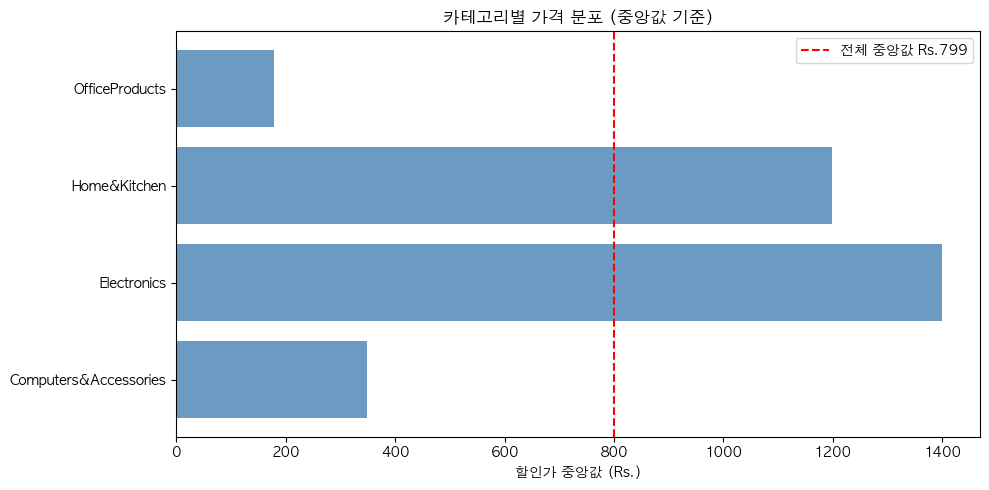

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

main_cats = price_by_cat[price_by_cat['상품수'] >= 10]

ax.barh(main_cats.index, main_cats['중앙값'], color='steelblue', alpha=0.8)
ax.set_xlabel('할인가 중앙값 (Rs.)')
ax.set_title('카테고리별 가격 분포 (중앙값 기준)')
ax.axvline(df['discounted_price'].median(), 
           color='red', linestyle='--', label=f'전체 중앙값 Rs.{df["discounted_price"].median():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

## 할인율 vs 평점 관계

In [4]:
rating_by_discount = df.groupby('discount_tier', observed=True)['rating'].agg(
    평균평점 = 'mean',
    상품수   = 'count'
).round(2)

print(rating_by_discount)

               평균평점  상품수
discount_tier           
0~20%          4.15  131
21~40%         4.13  338
41~60%         4.08  508
61~80%         4.08  380
81~100%        3.98   59


할인율이 높아질수록 평균 평점이 하락하는 패턴임.
81-100% 구간에서 평점이 가장 낮음 -> 과도한 할인은 상품의 신뢰도 저하를 가져올 수 있음을 시사

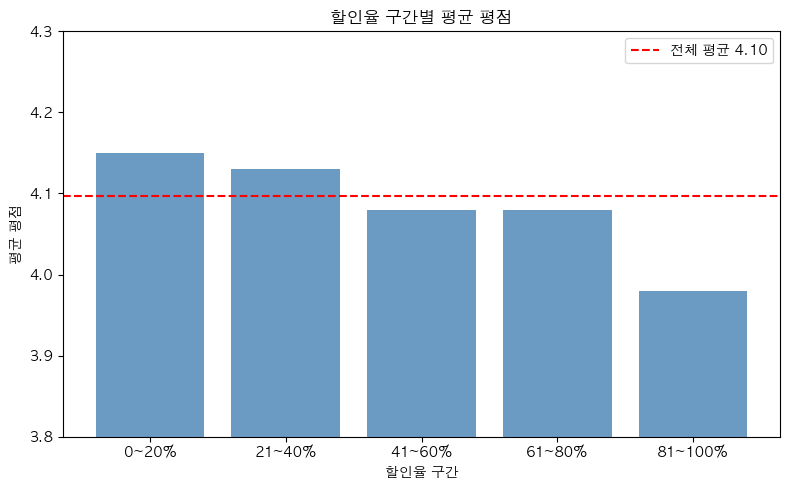

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(rating_by_discount.index, 
       rating_by_discount['평균평점'],
       color='steelblue', alpha=0.8)

ax.set_ylim(3.8, 4.3)
ax.set_xlabel('할인율 구간')
ax.set_ylabel('평균 평점')
ax.set_title('할인율 구간별 평균 평점')
ax.axhline(df['rating'].mean(), 
           color='red', linestyle='--',
           label=f'전체 평균 {df["rating"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

## 가격 vs 평점 관계

In [6]:
rating_by_price = df.groupby('price_tier', observed=True)['rating'].agg(
    평균평점 = 'mean',
    상품수   = 'count'
).round(2)

print(rating_by_price)

            평균평점  상품수
price_tier           
10K+        4.20  122
1K~3K       4.08  370
3K~10K      4.12  145
500~1K      4.12  252
~500        4.07  576


고가 상품 평점이 높음 -> 신중한 구매 + 만족도 높음, 저가 상품은 품질 저하 및 충동구매 확률 높음

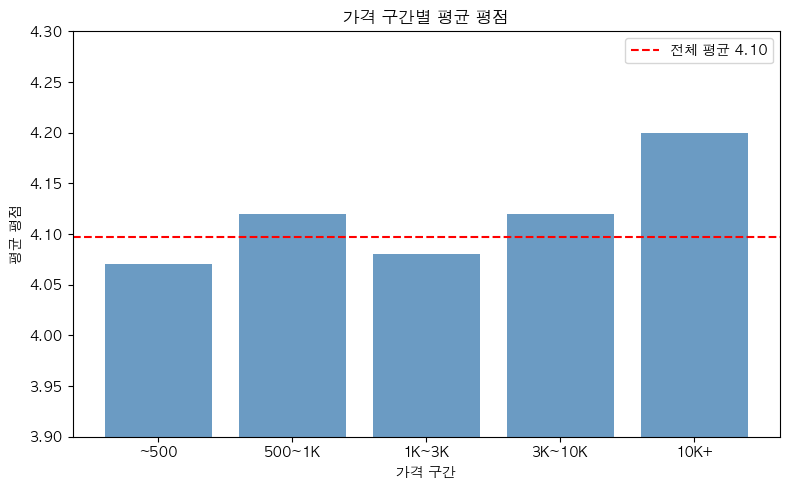

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

order = ['~500', '500~1K', '1K~3K', '3K~10K', '10K+']
data = rating_by_price.loc[order]

ax.bar(data.index, data['평균평점'], color='steelblue', alpha=0.8)
ax.set_ylim(3.9, 4.3)
ax.set_xlabel('가격 구간')
ax.set_ylabel('평균 평점')
ax.set_title('가격 구간별 평균 평점')
ax.axhline(df['rating'].mean(),
           color='red', linestyle='--',
           label=f'전체 평균 {df["rating"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

## 카테고리별 할인율 비교

In [8]:
discount_by_cat = df.groupby('category_main')['discount_percentage'].agg(
    평균할인율 = 'mean',
    중앙값    = 'median',
    상품수    = 'count'
).round(1)

# 상품 수 10개 이상만
discount_by_cat = discount_by_cat[discount_by_cat['상품수'] >= 10]
discount_by_cat = discount_by_cat.sort_values('평균할인율', ascending=False)

print(discount_by_cat)

                       평균할인율   중앙값  상품수
category_main                          
Computers&Accessories   54.0  58.0  453
Electronics             50.8  54.0  526
Home&Kitchen            40.1  41.5  448
OfficeProducts          12.4   5.0   31


높은 할인율 카테고리에서 평점 하락 리스크가 있음 -> 카테고리별 적정 할인율 구간 설정이 필요

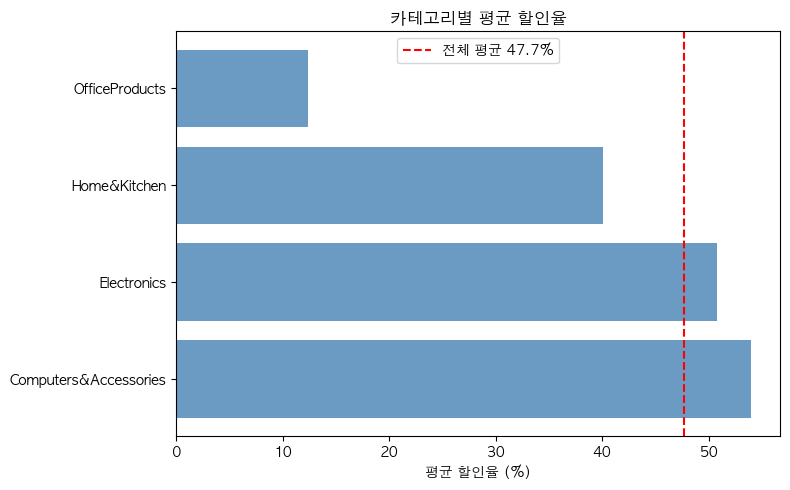

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(discount_by_cat.index, 
        discount_by_cat['평균할인율'],
        color='steelblue', alpha=0.8)

ax.set_xlabel('평균 할인율 (%)')
ax.set_title('카테고리별 평균 할인율')
ax.axvline(df['discount_percentage'].mean(),
           color='red', linestyle='--',
           label=f'전체 평균 {df["discount_percentage"].mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

## 핵심 인사이트
- 할인율이 높을수록 평균 평점이 낮아짐 (81~100% 구간이 가장 낮음)
- 고가 상품일수록 평점이 높음 (신중한 구매 + 품질 만족)
- 카테고리별 적정 할인율 가이드라인 설정 필요